# Designing partition-friendly QNNs — ansatz & encoding study
### Which architecture can you actually run across QPUs (and still train)?

Notebook 11 showed that distributed QNN deployment hinges on the circuit being *partition-friendly*. Here we
make that quantitative: across **entangling topologies** (`linear`, `blocks`, `ring`, `full`) and **data
encodings** (`angle`, re-uploading, `amplitude`) we measure three things per design:

* **trainability** — monolithic test accuracy,
* **partitionability** — how faithfully the best (PRISM-LCT) cut reconstructs the output (Q-Score), and
* **entanglement** across the cut — the physical reason a circuit is easy or hard to partition.

The result is concrete design guidance: low-entanglement, locally-structured ansätze are far easier to
distribute, amplitude encoding is the hardest to cut, and there is a genuine expressibility ↔
partitionability trade-off to navigate.

In [1]:
# ── Setup ──
%matplotlib inline
import sys, os, json, math, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for cand in ['../src', 'src', '.']:
    if os.path.isdir(os.path.join(cand, 'prism')):
        sys.path.insert(0, os.path.abspath(cand)); break
import prism
from prism import qml
from sklearn.model_selection import train_test_split

RESULTS = 'results'; os.makedirs(RESULTS, exist_ok=True)
SCALE = os.environ.get('PRISM_SCALE', 'small')
NQ = 6
# (encoding, entangler, data) configurations to compare
CONFIGS = [('reupload', 'linear', 'digits'), ('reupload', 'blocks', 'digits'),
           ('reupload', 'ring', 'digits'), ('reupload', 'full', 'digits'),
           ('angle', 'blocks', 'synth'), ('angle', 'ring', 'synth'),
           ('amplitude', 'blocks', 'digits')]
CFG = {'small': dict(reps=2, maxiter=45, n_train=28, n_test=30, q_samples=8),
       'full':  dict(reps=3, maxiter=120, n_train=80, n_test=80, q_samples=24)}[SCALE]
RECOMPUTE = os.environ.get('PRISM_RECOMPUTE', '0') == '1'

def cache_or_compute(path, fn, force=None):
    force = RECOMPUTE if force is None else force
    if (not force) and os.path.exists(path):
        return pd.read_csv(path)
    obj = fn(); obj.to_csv(path, index=False); return obj

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
                     'font.size': 9.5, 'axes.titleweight': 'bold', 'axes.grid': True, 'grid.alpha': 0.3})
print('prism', prism.__version__, '| n_qubits', NQ, '| configs', len(CONFIGS))

prism 0.1.0 | n_qubits 6 | configs 7


In [2]:
def _load(data):
    if data == 'synth':
        return qml.load_synth_qnn(n_features=NQ, n_qubits=NQ)
    return qml.load_qnn_dataset(data, n_qubits=NQ)

def _config_row(enc, ent, data):
    X, y, _, _ = _load(data)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
    Xte, yte = Xte[:CFG['n_test']], yte[:CFG['n_test']]
    if enc == 'amplitude':
        # amplitude state-prep is costly to train; partitionability (Q, entanglement)
        # is a structural property, so use fixed random weights and skip accuracy.
        w = np.random.default_rng(0).uniform(0, 2 * math.pi, size=qml.qnn_n_params(NQ, CFG['reps']))
        mono = float('nan')
    else:
        w, info = qml.train_qnn(Xtr, ytr, enc, NQ, reps=CFG['reps'], optimizer='COBYLA',
                                maxiter=CFG['maxiter'], seed=0, n_train=CFG['n_train'], entangler=ent)
        mono = qml.qnn_accuracy(Xte, yte, w, enc, NQ, CFG['reps'], entangler=ent)
    # best structure-aware cut (PRISM-LCT) on this circuit
    A, B = qml.qnn_cut_for(Xtr[0], w, enc, NQ, CFG['reps'], method='PRISM-LCT', seed=0, entangler=ent)
    # entanglement entropy across that cut + partition reconstruction fidelity, on test samples
    ents, qs, crosses = [], [], []
    for xi in Xte[:CFG['q_samples']]:
        lay = qml.qnn_circuit_layout(xi, w, enc, NQ, CFG['reps'], ent)
        qc, _ = prism.compile_circuit(lay, num_qubits=NQ)
        sv = prism.get_statevector(qc)
        ents.append(prism.entanglement_entropy(sv, sorted(A), NQ))
        pr = prism.reconstruct_product(A, B, lay, NQ)
        qs.append(prism.q_score(prism.distribution_metrics(prism.prob_from_statevector(sv), pr)))
        crosses.append(len(prism.classify_gates(lay, A, B)['cross']))
    dist_acc = qml.qnn_distributed_accuracy(Xte, yte, w, enc, NQ, CFG['reps'], A, B, entangler=ent)
    return dict(encoding=enc, entangler=ent, data=data, config=f'{enc}/{ent}',
                mono_acc=mono, dist_acc=dist_acc, recon_q=float(np.mean(qs)),
                entanglement=float(np.mean(ents)), cross_gates=float(np.mean(crosses)))

def compute_ansatz():
    return pd.DataFrame([_config_row(*c) for c in CONFIGS])

df = cache_or_compute(f'{RESULTS}/nb12_ansatz.csv', compute_ansatz)
df['label'] = df['encoding'] + '/' + df['entangler']
print(df[['encoding', 'entangler', 'data', 'mono_acc', 'dist_acc', 'recon_q', 'entanglement', 'cross_gates']].round(3).to_string(index=False))

 encoding entangler   data  mono_acc  dist_acc  recon_q  entanglement  cross_gates
amplitude    blocks digits       NaN     0.567    0.624         1.753         16.0
    angle    blocks  synth     0.700     0.533    0.552         0.823          2.0
    angle      ring  synth     0.433     0.400    0.748         0.931          4.0
 reupload    blocks digits     0.500     0.367    0.739         0.734          2.0
 reupload      full digits     0.433     0.467    0.623         1.401         16.0
 reupload    linear digits     0.533     0.533    0.796         0.678          2.0
 reupload      ring digits     0.533     0.533    0.638         1.479          4.0


## 2. The expressibility ↔ partitionability trade-off

Each design as a point: trainability (monolithic accuracy) vs partitionability (reconstruction Q). The
ideal corner is top-right — but highly expressive (entangling) ansätze tend to sit lower on
partitionability. Marker size encodes entanglement across the cut.

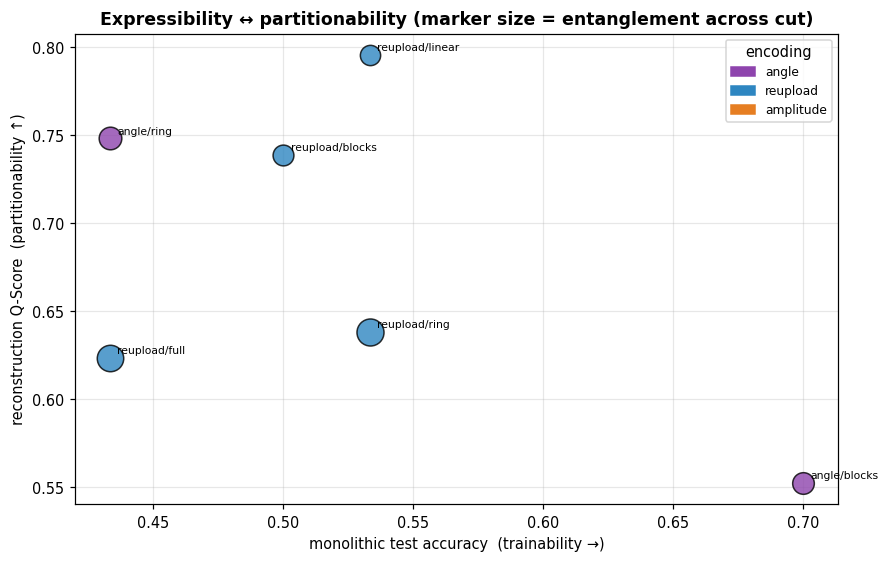

In [4]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))
for _, r in df.iterrows():
    ax.scatter(r.mono_acc, r.recon_q, s=60 + 300 * r.entanglement / max(df.entanglement.max(), 1e-9),
               alpha=0.8, edgecolor='k',
               color={'angle': '#8E44AD', 'reupload': '#2E86C1', 'amplitude': '#E67E22'}[r.encoding], zorder=3)
    ax.annotate(r.label, (r.mono_acc, r.recon_q), fontsize=7, xytext=(5, 3), textcoords='offset points')
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color='#8E44AD', label='angle'),
                   mpatches.Patch(color='#2E86C1', label='reupload'),
                   mpatches.Patch(color='#E67E22', label='amplitude')], title='encoding', fontsize=8)
ax.set_xlabel('monolithic test accuracy  (trainability →)')
ax.set_ylabel('reconstruction Q-Score  (partitionability ↑)')
ax.set_title('Expressibility ↔ partitionability (marker size = entanglement across cut)')
fig.tight_layout(); fig.savefig(f'{RESULTS}/nb12_f02_tradeoff.png'); plt.show()

## 3. Encoding matters too: amplitude encoding is hardest to cut

Amplitude encoding packs all features into a maximally dense state-prep circuit — highly entangled and the
least partition-friendly. Angle / re-uploading encodings leave more structure for a partitioner to exploit.

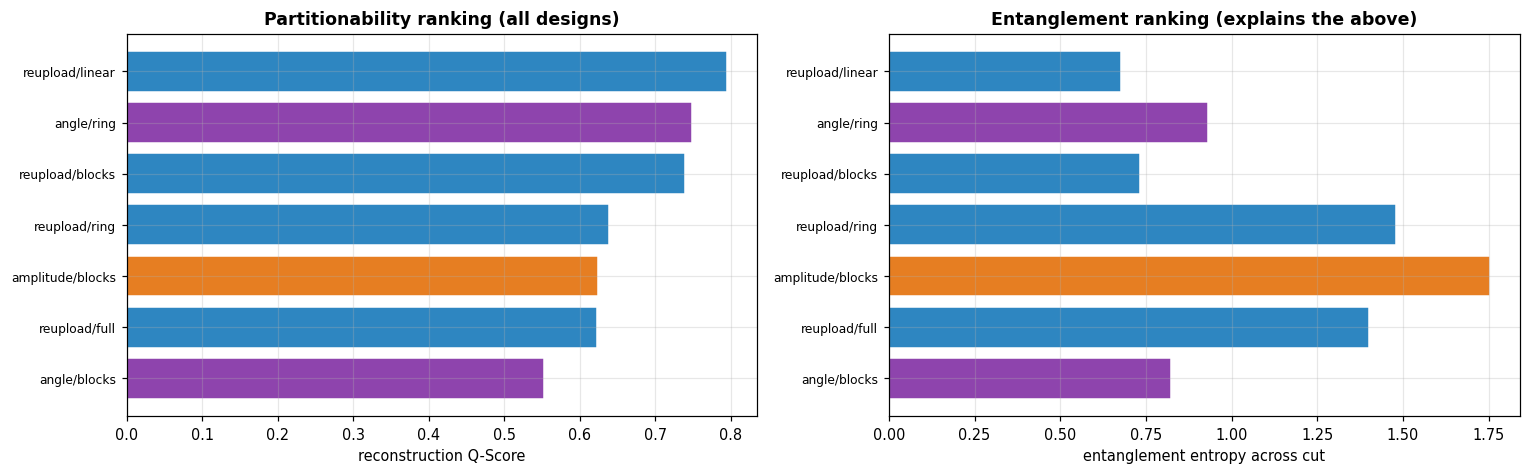

In [5]:
order = df.sort_values('recon_q')
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
cmap = {'angle': '#8E44AD', 'reupload': '#2E86C1', 'amplitude': '#E67E22'}
ax[0].barh(range(len(order)), order.recon_q.values, color=[cmap[e] for e in order.encoding], edgecolor='white')
ax[0].set_yticks(range(len(order))); ax[0].set_yticklabels(order.label.values, fontsize=8)
ax[0].set_xlabel('reconstruction Q-Score'); ax[0].set_title('Partitionability ranking (all designs)')
ax[1].barh(range(len(order)), order.entanglement.values, color=[cmap[e] for e in order.encoding], edgecolor='white')
ax[1].set_yticks(range(len(order))); ax[1].set_yticklabels(order.label.values, fontsize=8)
ax[1].set_xlabel('entanglement entropy across cut'); ax[1].set_title('Entanglement ranking (explains the above)')
fig.tight_layout(); fig.savefig(f'{RESULTS}/nb12_f03_encoding.png'); plt.show()